# RegBN Multimodal Testing
Contribution by Lyder Samnøy

This notebook tests RegBN in the same multimodal setting used by the main project:
- economic tabular features
- Sentinel-2 + VIIRS imagery
- combined model, Japan-only model, and Philippines-only model

RegBN is implemented between the modality encoders and the fusion block


In [1]:
import copy
import datetime
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

from Notebooks.RegBN_environment import (
    ConstructionCostRegBNModel,
    ConstructionDataset,
    RegBNContext,
    collate_fn,
    geolocation_temporal_interpolation,
    load_tensor_dict,
    rmsle_loss,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


ModuleNotFoundError: No module named 'Notebooks'

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


In [ ]:
ROOT = Path("..")
DATA_PATH = ROOT / "Processed data"
IMG_PATH = DATA_PATH / "processed_composite"
MODEL_PATH = ROOT / "Models"

tensor_dict = load_tensor_dict(IMG_PATH)

full_df = pd.read_csv(DATA_PATH / "processed_data.csv")
japan_df = pd.read_csv(DATA_PATH / "processed_japan.csv")
philippines_df = pd.read_csv(DATA_PATH / "processed_philippines.csv")
eval_df = pd.read_csv(DATA_PATH / "processed_eval.csv")

split_dfs = {
    "full": full_df,
    "japan": japan_df,
    "philippines": philippines_df,
}

for name, df in split_dfs.items():
    print(f"{name}: {df.shape}")
print(f"eval: {eval_df.shape}")


full: (1024, 20)
japan: (567, 17)
philippines: (457, 19)
eval: (1024, 19)


## Experiment Setup

The baseline hyperparameters below come from the best runs already reported in `NNpipeline.ipynb`.
Start with `REGBN_MODE = "bidirectional"` to remove tabular-implied image structure and image-implied tabular structure before fusion.


In [ ]:
BEST_PARAMS = {
    "full": {
        "epochs": 50,
        "learning_rate": 0.003,
        "weight_decay": 0.0001,
        "patience": 10,
        "factor": 0.1,
        "batch_size": 128,
        "dropout": 0.3,
        "augment": False,
        "max_missing": 1,
    },
    "japan": {
        "epochs": 50,
        "learning_rate": 0.003,
        "weight_decay": 0.0001,
        "patience": 10,
        "factor": 0.5,
        "batch_size": 128,
        "dropout": 0.5,
        "augment": True,
        "max_missing": None,
    },
    "philippines": {
        "epochs": 50,
        "learning_rate": 0.003,
        "weight_decay": 0.001,
        "patience": 10,
        "factor": 0.5,
        "batch_size": 128,
        "dropout": 0.3,
        "augment": True,
        "max_missing": 1,
    },
}

EXPERIMENT_PREFIX = "regbn_bidirectional"
REGBN_MODE = "bidirectional"   # one of: "image", "tabular", "bidirectional"
REGBN_CONFIG = {
    "regbn_mode": REGBN_MODE,
    "regbn_normalize_input": True,
    "regbn_normalize_output": True,
    "regbn_sigma_thr": 0.0,
    "regbn_sigma_min": 0.0,
    "regbn_momentum": 0.02,
    "regbn_projection_clip_value": 10.0,
    "regbn_verbose": False,
}

RUN_TRAINING = False
RUN_SUBMISSION = False
SAVE_PLOTS = True

BEST_PARAMS


{'full': {'epochs': 50,
  'learning_rate': 0.003,
  'weight_decay': 0.0001,
  'patience': 10,
  'factor': 0.1,
  'batch_size': 128,
  'dropout': 0.3,
  'augment': False,
  'max_missing': 1},
 'japan': {'epochs': 50,
  'learning_rate': 0.003,
  'weight_decay': 0.0001,
  'patience': 10,
  'factor': 0.5,
  'batch_size': 128,
  'dropout': 0.5,
  'augment': True,
  'max_missing': None},
 'philippines': {'epochs': 50,
  'learning_rate': 0.003,
  'weight_decay': 0.001,
  'patience': 10,
  'factor': 0.5,
  'batch_size': 128,
  'dropout': 0.3,
  'augment': True,
  'max_missing': 1}}

In [ ]:
def train_model(model, optimizer, scheduler, train_loader, val_loader, epochs):
    train_losses = []
    val_losses = []
    best_model_state = None
    best_val_loss = float("inf")
    best_epoch = None
    steps_per_epoch = max(len(train_loader), 1)

    print(f"{datetime.datetime.now().time()} | Starting training...")

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        for _, continuous, categoricals, images, target in train_loader:
            continuous = continuous.to(device)
            categoricals = {k: v.to(device) for k, v in categoricals.items()}
            images = images.to(device)
            target = target.to(device)

            optimizer.zero_grad()
            regbn_context = RegBNContext(is_training=True, n_epoch=epoch - 1, steps_per_epoch=steps_per_epoch)
            pred = model(continuous, categoricals, images, regbn_context=regbn_context)
            loss = rmsle_loss(pred, target)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item() * len(target)

        avg_train_loss = total_loss / len(train_loader.dataset)
        train_losses.append(avg_train_loss)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for _, continuous, categoricals, images, target in val_loader:
                continuous = continuous.to(device)
                categoricals = {k: v.to(device) for k, v in categoricals.items()}
                images = images.to(device)
                target = target.to(device)
                regbn_context = RegBNContext(is_training=False, n_epoch=epoch - 1, steps_per_epoch=steps_per_epoch)
                pred = model(continuous, categoricals, images, regbn_context=regbn_context)
                loss = rmsle_loss(pred, target)
                val_loss += loss.item() * len(target)

        avg_val_loss = val_loss / len(val_loader.dataset)
        val_losses.append(avg_val_loss)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch

        if scheduler is not None:
            scheduler.step(avg_val_loss)

        if epoch in (1, epochs) or epoch % 10 == 0:
            print(f"{datetime.datetime.now().time()} | Epoch {epoch} | train {avg_train_loss:.4f} | val {avg_val_loss:.4f}")

    return train_losses, val_losses, best_model_state, best_val_loss, best_epoch


def train_on_df(df, split_name, params):
    train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)
    train_df, split_tensor_dict = geolocation_temporal_interpolation(train_df, tensor_dict, params["max_missing"])

    train_dataset = ConstructionDataset(train_df, tensor_dict=split_tensor_dict, augment=params["augment"])
    val_dataset = ConstructionDataset(val_df, tensor_dict=split_tensor_dict, augment=False)

    train_loader = DataLoader(train_dataset, batch_size=params["batch_size"], shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(val_dataset, batch_size=params["batch_size"], shuffle=False, collate_fn=collate_fn)

    model = ConstructionCostRegBNModel(df=df, device=device, dropout=params["dropout"], **REGBN_CONFIG).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=params["learning_rate"], weight_decay=params["weight_decay"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=params["patience"], factor=params["factor"])

    train_losses, val_losses, best_model_state, best_val_loss, best_epoch = train_model(
        model, optimizer, scheduler, train_loader, val_loader, epochs=params["epochs"]
    )

    model_name = f"{split_name}_{EXPERIMENT_PREFIX}"
    torch.save({
        "model": best_model_state,
        "best_loss": best_val_loss,
        "best_epoch": best_epoch,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "training_data": train_df,
        "validation_data": val_df,
        "regbn_config": REGBN_CONFIG,
        "baseline_params": params,
    }, MODEL_PATH / f"{model_name}.pth")

    return model_name, best_val_loss, best_epoch


In [ ]:
if RUN_TRAINING:
    results = {}
    for split_name, df in split_dfs.items():
        print(f"\nTraining {split_name} with RegBN mode = {REGBN_MODE}")
        model_name, best_loss, best_epoch = train_on_df(df, split_name, BEST_PARAMS[split_name])
        results[split_name] = {"model_name": model_name, "best_loss": best_loss, "best_epoch": best_epoch}
    results
else:
    print("Set RUN_TRAINING = True to train the RegBN models.")


Set RUN_TRAINING = True to train the RegBN models.


In [ ]:
def evaluate_checkpoint(split_name):
    checkpoint_path = MODEL_PATH / f"{split_name}_{EXPERIMENT_PREFIX}.pth"
    checkpoint = torch.load(checkpoint_path, weights_only=False)
    print(f"{split_name}: best loss = {checkpoint['best_loss']:.6f}, best epoch = {checkpoint['best_epoch']}")
    return checkpoint


def plot_losses(split_name):
    checkpoint = torch.load(MODEL_PATH / f"{split_name}_{EXPERIMENT_PREFIX}.pth", weights_only=False)
    train_losses = checkpoint["train_losses"]
    val_losses = checkpoint["val_losses"]
    plt.figure(figsize=(9, 5))
    plt.plot(train_losses, label="Train")
    plt.plot(val_losses, label="Validation")
    plt.title(f"{split_name} | {EXPERIMENT_PREFIX}")
    plt.xlabel("Epoch")
    plt.ylabel("RMSLE")
    plt.grid(True)
    plt.legend()
    if SAVE_PLOTS:
        plt.savefig(MODEL_PATH / f"{split_name}_{EXPERIMENT_PREFIX}_loss.png", bbox_inches="tight")
    plt.show()


available_splits = [
    split_name for split_name in split_dfs.keys()
    if (MODEL_PATH / f"{split_name}_{EXPERIMENT_PREFIX}.pth").exists()
]

if available_splits:
    checkpoints = {name: evaluate_checkpoint(name) for name in available_splits}
    if {"japan", "philippines"}.issubset(checkpoints):
        combined_split_loss = (
            len(japan_df) / len(full_df) * checkpoints["japan"]["best_loss"]
            + len(philippines_df) / len(full_df) * checkpoints["philippines"]["best_loss"]
        )
        print(f"Weighted Japan + Philippines loss: {combined_split_loss:.6f}")
else:
    print("No RegBN checkpoints found yet. Train first or point EXPERIMENT_PREFIX at existing checkpoints.")


full: best loss = 0.215939, best epoch = 25
japan: best loss = 0.142054, best epoch = 44
philippines: best loss = 0.300162, best epoch = 40
Weighted Japan + Philippines loss: 0.212616


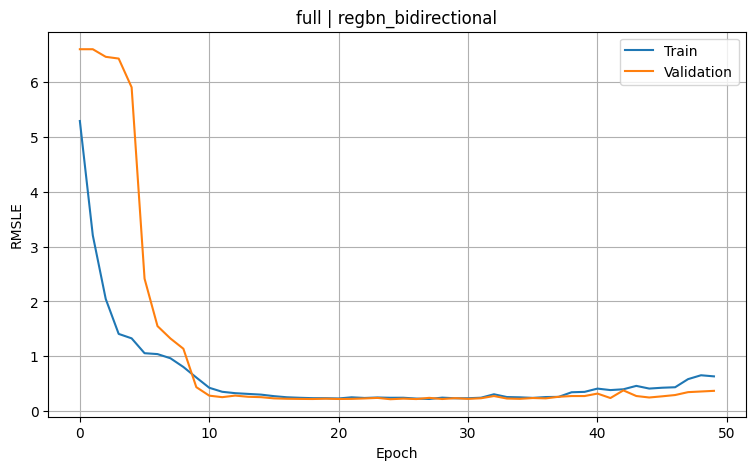

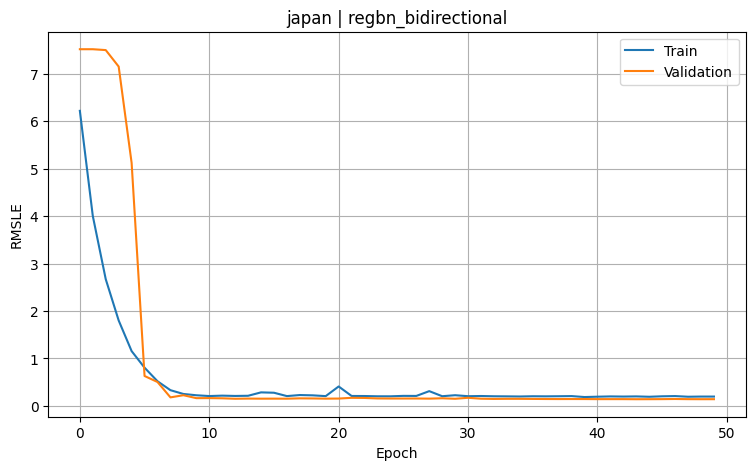

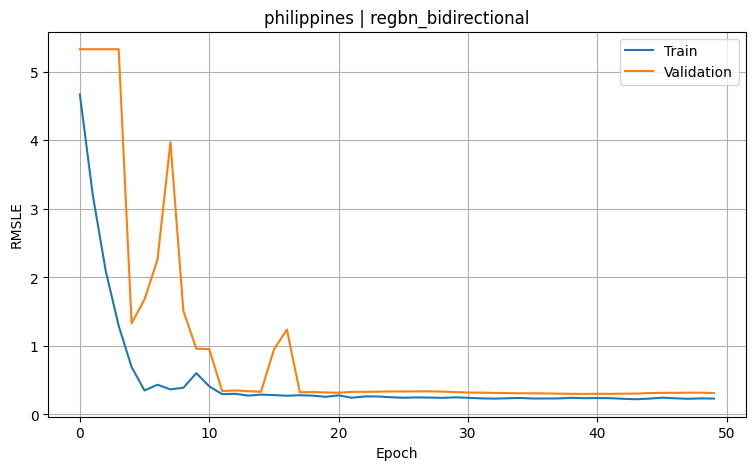

In [ ]:
for split_name in split_dfs.keys():
    checkpoint_path = MODEL_PATH / f"{split_name}_{EXPERIMENT_PREFIX}.pth"
    if checkpoint_path.exists():
        plot_losses(split_name)


In [ ]:
def build_model_from_checkpoint(df, split_name):
    checkpoint = torch.load(MODEL_PATH / f"{split_name}_{EXPERIMENT_PREFIX}.pth", weights_only=False)
    model = ConstructionCostRegBNModel(df=df, device=device, dropout=checkpoint["baseline_params"]["dropout"], **checkpoint["regbn_config"]).to(device)
    model.load_state_dict(checkpoint["model"])
    model.eval()
    return model


if RUN_SUBMISSION:
    submission_path = ROOT / "Submissions"
    eval_dataset = ConstructionDataset(eval_df, tensor_dict)

    full_model = build_model_from_checkpoint(full_df, "full")
    japan_model = build_model_from_checkpoint(japan_df, "japan")
    philippines_model = build_model_from_checkpoint(philippines_df, "philippines")

    full_predictions = []
    split_predictions = []
    data_ids = []

    for data_id, continuous, categoricals, images, _ in eval_dataset:
        data_ids.append(data_id)
        country = categoricals["country"].item()
        cont = continuous.unsqueeze(0).to(device)
        cats = {k: v.unsqueeze(0).to(device) for k, v in categoricals.items()}
        imgs = images.unsqueeze(0).to(device)
        infer_ctx = RegBNContext(is_training=False, n_epoch=0, steps_per_epoch=1)

        with torch.no_grad():
            full_pred = full_model(cont, cats, imgs, regbn_context=infer_ctx)
            split_pred = philippines_model(cont, cats, imgs, regbn_context=infer_ctx) if country == 0 else japan_model(cont, cats, imgs, regbn_context=infer_ctx)

        full_predictions.append(full_pred.item())
        split_predictions.append(split_pred.item())

    pd.DataFrame({
        "data_id": data_ids,
        "construction_cost_per_m2_usd": full_predictions,
    }).to_csv(submission_path / f"full_{EXPERIMENT_PREFIX}.csv", index=False)

    pd.DataFrame({
        "data_id": data_ids,
        "construction_cost_per_m2_usd": split_predictions,
    }).to_csv(submission_path / f"split_{EXPERIMENT_PREFIX}.csv", index=False)

    print("Saved RegBN submissions to the Submissions directory.")
else:
    print("Set RUN_SUBMISSION = True after training checkpoints are available.")


Set RUN_SUBMISSION = True after training checkpoints are available.


## RegBN Validation

This section validates what RegBN changes on the saved validation split for each trained checkpoint.
It compares tabular and image embeddings before and after the RegBN block, then measures how much the embeddings change and whether the average cross-modal correlation is reduced.


In [ ]:
def mean_abs_cross_corr(a, b):
    a = a.float()
    b = b.float()
    a_centered = a - a.mean(dim=0, keepdim=True)
    b_centered = b - b.mean(dim=0, keepdim=True)
    denom = max(a.shape[0] - 1, 1)
    cov = (a_centered.T @ b_centered) / denom
    a_std = a_centered.std(dim=0, unbiased=False).clamp_min(1e-6)
    b_std = b_centered.std(dim=0, unbiased=False).clamp_min(1e-6)
    corr = cov / (a_std.unsqueeze(1) * b_std.unsqueeze(0))
    corr = torch.nan_to_num(corr, nan=0.0, posinf=0.0, neginf=0.0)
    return corr.abs().mean().item(), corr.cpu().numpy()


def relative_change(before, after):
    return ((before - after).norm(dim=1) / (before.norm(dim=1) + 1e-6)).cpu().numpy()


def collect_regbn_validation(split_name, batch_size=256):
    checkpoint_path = MODEL_PATH / f"{split_name}_{EXPERIMENT_PREFIX}.pth"
    if not checkpoint_path.exists():
        raise FileNotFoundError(f"Missing checkpoint: {checkpoint_path}")

    checkpoint = torch.load(checkpoint_path, weights_only=False)
    val_df = checkpoint["validation_data"].copy()
    source_df = split_dfs[split_name]
    model = build_model_from_checkpoint(source_df, split_name)
    dataset = ConstructionDataset(val_df, tensor_dict=tensor_dict, augment=False)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

    tab_before_all = []
    tab_after_all = []
    img_before_all = []
    img_after_all = []
    pred_before_all = []
    pred_after_all = []
    target_all = []

    model.eval()
    with torch.no_grad():
        for _, continuous, categoricals, images, target in loader:
            continuous = continuous.to(device)
            categoricals = {k: v.to(device) for k, v in categoricals.items()}
            images = images.to(device)
            target = target.to(device)

            tab_before = model.tabular_encoder(continuous, categoricals)
            img_before = model.image_encoder(images)

            if model.regbn is not None:
                tab_after, img_after = model.regbn(
                    tab_before,
                    img_before,
                    context=RegBNContext(is_training=False, n_epoch=0, steps_per_epoch=max(len(loader), 1)),
                )
            else:
                tab_after, img_after = tab_before, img_before

            fused_before = model.fusion(tab_before, img_before)
            fused_after = model.fusion(tab_after, img_after)
            pred_before = model.regression_head(fused_before).squeeze(1)
            pred_after = model.regression_head(fused_after).squeeze(1)

            tab_before_all.append(tab_before.cpu())
            tab_after_all.append(tab_after.cpu())
            img_before_all.append(img_before.cpu())
            img_after_all.append(img_after.cpu())
            pred_before_all.append(pred_before.cpu())
            pred_after_all.append(pred_after.cpu())
            target_all.append(target.cpu())

    tab_before = torch.cat(tab_before_all, dim=0)
    tab_after = torch.cat(tab_after_all, dim=0)
    img_before = torch.cat(img_before_all, dim=0)
    img_after = torch.cat(img_after_all, dim=0)
    pred_before = torch.cat(pred_before_all, dim=0)
    pred_after = torch.cat(pred_after_all, dim=0)
    targets = torch.cat(target_all, dim=0)

    tab_corr_before, _ = mean_abs_cross_corr(tab_before, img_before)
    tab_corr_after, _ = mean_abs_cross_corr(tab_after, img_after)

    tab_delta = relative_change(tab_before, tab_after)
    img_delta = relative_change(img_before, img_after)
    pred_delta = (pred_after - pred_before).abs().cpu().numpy()

    corr_reduction = 0.0
    if abs(tab_corr_before) > 1e-8:
        corr_reduction = 100.0 * (1.0 - tab_corr_after / tab_corr_before)

    pred_before_mean = float(pred_before.mean().item())
    pred_after_mean = float(pred_after.mean().item())
    target_mean = float(targets.mean().item())
    pred_before_target_gap = abs(pred_before_mean - target_mean)
    pred_after_target_gap = abs(pred_after_mean - target_mean)

    summary = {
        "split": split_name,
        "n_validation": len(val_df),
        "tab_change_%": 100.0 * float(tab_delta.mean()),
        "img_change_%": 100.0 * float(img_delta.mean()),
        "tab_img_corr_before": tab_corr_before,
        "tab_img_corr_after": tab_corr_after,
        "tab_img_corr_reduction_%": corr_reduction,
        "pred_shift_mean": float(pred_delta.mean()),
        "pred_shift_median": float(np.median(pred_delta)),
        "pred_before_mean": pred_before_mean,
        "pred_after_mean": pred_after_mean,
        "target_mean": target_mean,
        "pred_before_target_gap": pred_before_target_gap,
        "pred_after_target_gap": pred_after_target_gap,
        "target_gap_change": pred_after_target_gap - pred_before_target_gap,
        "dependence_direction": "reduced" if tab_corr_after < tab_corr_before else "increased",
        "prediction_alignment": "improved" if pred_after_target_gap < pred_before_target_gap else "worsened",
    }

    payload = {
        "summary": summary,
        "tab_delta": tab_delta,
        "img_delta": img_delta,
        "pred_before": pred_before.numpy(),
        "pred_after": pred_after.numpy(),
        "targets": targets.numpy(),
    }
    return payload


In [ ]:
validation_results = []
validation_payloads = {}

for split_name in split_dfs.keys():
    checkpoint_path = MODEL_PATH / f"{split_name}_{EXPERIMENT_PREFIX}.pth"
    if checkpoint_path.exists():
        payload = collect_regbn_validation(split_name)
        validation_payloads[split_name] = payload
        validation_results.append(payload["summary"])

validation_df = pd.DataFrame(validation_results)
if not validation_df.empty:
    display_cols = [
        "split",
        "n_validation",
        "tab_change_%",
        "img_change_%",
        "tab_img_corr_before",
        "tab_img_corr_after",
        "tab_img_corr_reduction_%",
        "dependence_direction",
        "pred_shift_mean",
        "pred_before_target_gap",
        "pred_after_target_gap",
        "target_gap_change",
        "prediction_alignment",
    ]
    validation_df = validation_df[display_cols].sort_values("split").reset_index(drop=True)
    validation_df = validation_df.round({
        "tab_change_%": 2,
        "img_change_%": 2,
        "tab_img_corr_before": 6,
        "tab_img_corr_after": 6,
        "tab_img_corr_reduction_%": 2,
        "pred_shift_mean": 2,
        "pred_before_target_gap": 2,
        "pred_after_target_gap": 2,
        "target_gap_change": 2,
    })
validation_df


,split,n_validation,tab_change_%,img_change_%,tab_img_corr_before,tab_img_corr_after,tab_img_corr_reduction_%,dependence_direction,pred_shift_mean,pred_before_target_gap,pred_after_target_gap,target_gap_change,prediction_alignment
0,full,205,75.77,92.52,0.006682,0.835172,-12399.10,increased,2601.01,2585.59,11.77,-2573.82,improved
1,japan,114,72.78,306.91,0.066670,0.161782,-142.66,increased,1070.14,1041.21,25.93,-1015.28,improved
2,philippines,92,69.84,101.82,0.022988,0.294209,-1179.85,increased,112.16,80.10,7.69,-72.42,improved


In [ ]:
for split_name, payload in validation_payloads.items():
    print(f"\n=== {split_name.upper()} RegBN validation ===")
    summary = payload["summary"]
    ordered_keys = [
        "n_validation",
        "tab_change_%",
        "img_change_%",
        "tab_img_corr_before",
        "tab_img_corr_after",
        "tab_img_corr_reduction_%",
        "dependence_direction",
        "pred_shift_mean",
        "pred_shift_median",
        "pred_before_mean",
        "pred_after_mean",
        "target_mean",
        "pred_before_target_gap",
        "pred_after_target_gap",
        "target_gap_change",
        "prediction_alignment",
    ]
    for key in ordered_keys:
        value = summary[key]
        if isinstance(value, float):
            print(f"{key}: {value:.6f}")
        else:
            print(f"{key}: {value}")



=== FULL RegBN validation ===
n_validation: 205
tab_change_%: 75.772226
img_change_%: 92.520708
tab_img_corr_before: 0.006682
tab_img_corr_after: 0.835172
tab_img_corr_reduction_%: -12399.099746
dependence_direction: increased
pred_shift_mean: 2601.006592
pred_shift_median: 1160.790039
pred_before_mean: 3685.300537
pred_after_mean: 1087.942993
target_mean: 1099.713135
pred_before_target_gap: 2585.587402
pred_after_target_gap: 11.770142
target_gap_change: -2573.817261
prediction_alignment: improved

=== JAPAN RegBN validation ===
n_validation: 114
tab_change_%: 72.782630
img_change_%: 306.906509
tab_img_corr_before: 0.066670
tab_img_corr_after: 0.161782
tab_img_corr_reduction_%: -142.661409
dependence_direction: increased
pred_shift_mean: 1070.136475
pred_shift_median: 1050.217041
pred_before_mean: 2897.873535
pred_after_mean: 1830.730225
target_mean: 1856.659546
pred_before_target_gap: 1041.213989
pred_after_target_gap: 25.929321
target_gap_change: -1015.284668
prediction_alignment: i